## Mediocre ML Model for Humanity Score

In [1]:
import numpy as np
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import Normalization
import os
import json

In [2]:
def data_handler_VAR(data, max_length):
    d = np.zeros((len(data), max_length, 2))
    for line in range(len(data)):
        tmp = data[line]
        l = len(tmp)
        if l < max_length:
            for i in range(max_length-l):
                tmp.append(data[line][-1])
        else:
            tmp = tmp[:max_length]                
        d[line,::] = np.array(tmp)
    layer = Normalization(axis=1)
    layer.adapt(d)
    # trains = layer(d)
    return d

def handle_data(data, labels, max_length):
    new_data, new_labels = [], []
    for idx, session in enumerate(data):
        cur_label = labels[idx]
        session_length = len(session)
        cur = 0
        while cur * max_length + max_length <= session_length:
            new_data.append(session[cur * max_length: (cur + 1) * max_length])
            new_labels.append(cur_label)
            cur += 1
        
        last_section = session[cur * max_length:]
        last_section += [session[-1] for _ in range(max_length - len(last_section))]
        new_data.append(last_section)
        new_labels.append(cur_label)

    new_data, new_labels = np.array(new_data), np.array(new_labels)
    layer = Normalization(axis=1)
    layer.adapt(new_data)
    # trains = layer(d)
    return new_data, new_labels

def load(path="mydata/data", max_length=100):
    files = os.listdir(path)
    data = []
    labels = []
    for file in files:
        with open(os.path.join(path, file), "r") as f:
            dct = json.load(f)
        mouse = dct["mouse_movements"]
        if not mouse:
            continue
        entry = [[i['x'], i['y']] for i in mouse]
        data.append(entry)
        
        if file.startswith("human"):
            labels.append(0)
        elif file.startswith("bot"):
            labels.append(1)
    
    # for i in data:
    #     print(len(i))
    # data = data_handler_VAR(data, max_length=max_length)   labels = np.array(labels)
    data, labels = handle_data(data, labels, max_length=max_length)
    return data, labels

data, labels = load(max_length=100, path="../train_data")

# from sklearn.model_selection import train_test_split
# # Assuming data and labels are NumPy arrays
# x_train, x_test, y_train, y_test = train_test_split(
#     data, labels, test_size=0.01, shuffle=True, random_state=42
# )

x_train, y_train = data, labels

In [4]:
n_timesteps, n_features = x_train.shape[1], x_train.shape[2]
x_train.shape, y_train.shape

((239, 100, 2), (239,))

In [22]:
x_train

array([[[ 874,  201],
        [ 896,  184],
        [ 918,  166],
        ...,
        [1104,   32],
        [1104,   32],
        [1104,   32]],

       [[ 683,  384],
        [ 730,  351],
        [ 776,  318],
        ...,
        [ 884,  592],
        [ 884,  592],
        [ 884,  592]],

       [[ 683,  384],
        [ 660,  375],
        [ 638,  366],
        ...,
        [ 379,  370],
        [ 355,  372],
        [ 331,  375]],

       ...,

       [[ 711,  362],
        [ 711,  362],
        [ 711,  362],
        ...,
        [ 711,  362],
        [ 711,  362],
        [ 711,  362]],

       [[ 544,  251],
        [ 543,  251],
        [ 176,  423],
        ...,
        [ 657,  323],
        [ 657,  323],
        [ 657,  323]],

       [[ 308,  327],
        [ 308,  326],
        [ 307,  325],
        ...,
        [1128,  155],
        [1128,  155],
        [1128,  155]]], shape=(283, 100, 2))

In [6]:
model = Sequential()
model.add(LSTM(200, input_shape=(n_timesteps, n_features)))
model.add(Dense(100, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 200)            │       162,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,601 (713.29 KB)

 Trainable params: 182,601 (713.29 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
x_train.shape, x_test.shape, y_train.shape, y_test.shape

NameError: name 'x_test' is not defined

In [8]:
import tensorflow as tf
file = "models/big_model.keras"
model = tf.keras.models.load_model(file)
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                  │ (None, 100, 200)       │       162,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 912,149 (3.48 MB)

 Trainable params: 304,049 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 608,100 (2.32 MB)

In [9]:
verbose, epochs, batch_size = 1, 4, 64

# model.fit(x_train, y_train, epochs=epochs, batch_size=batch_size, verbose=verbose)
# evaluate model
_, accuracy = model.evaluate(x_train, y_train, batch_size=batch_size, verbose=0)
accuracy

0.9748954176902771

In [10]:
_, accuracy = model.evaluate(x_test, y_test, batch_size=batch_size, verbose=0)
accuracy

NameError: name 'x_test' is not defined

In [65]:
model_filename = "mid_model.keras"

model.save(f"models/{model_filename}")

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 100, 200)       │       162,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 100)            │       120,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 304,049 (1.16 MB)

 Trainable params: 304,049 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


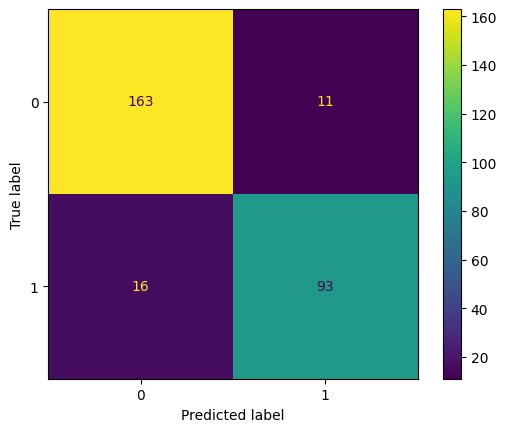

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_train, np.round(model.predict(x_train)))

In [74]:
ConfusionMatrixDisplay.from_predictions(y_test, np.round(model.predict(x_test)))

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - accuracy: 0.6694 - loss: 0.6372
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - accuracy: 0.7790 - loss: 0.5055
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 148ms/step - accuracy: 0.9183 - loss: 0.3192
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - accuracy: 0.9100 - loss: 0.2493
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.9257 - loss: 0.1856


0.9536178112030029

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step


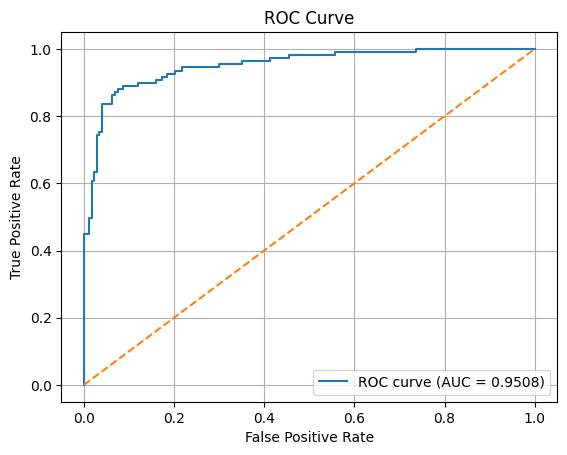

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities for the positive class
y_scores = model.predict(x_train)  
# If your model doesn't support predict_proba, use:
# y_scores = model.decision_function(X_train)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_train, y_scores)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random classifier line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()